## 📊 Data Analysis

This notebook analyzes primary-level learning outcomes among refugee students,
focusing on math and reading performance. The goal is to
identify disparities and trends that relate to **Research Question 1**.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
math = pd.read_csv("clean_math_primary_structured.csv")
read = pd.read_csv("clean_read_primary_structured.csv")
ref_income = pd.read_csv("school_age_refugee_population_by_income.csv")
ref_region = pd.read_csv("school_age_refugee_population_by_region.csv")

In [5]:
print("math:", math.shape)
print("read:", read.shape)
print("ref_income:", ref_income.shape)
print("ref_region:", ref_region.shape)

math.head()

math: (558, 6)
read: (488, 6)
ref_income: (88, 3)
ref_region: (154, 3)


,indicator_id,year,math_primary_score,data_quality,geo_group_type,geo_group_name
0,MATH.PRIMARY,2000,22.50883,UIS_EST,GPE,"Overall FY24, all 90 countries, December 2024"
1,MATH.PRIMARY,2000,71.70074,UIS_EST,SDG,Europe and Northern America
2,MATH.PRIMARY,2000,51.24175,UIS_EST,SDG,Latin America and the Caribbean
3,MATH.PRIMARY,2000,24.79222,UIS_EST,SDG,Northern Africa and Western Asia
4,MATH.PRIMARY,2000,61.73769,UIS_EST,SDG,Oceania


In [6]:
def norm_cols(df):
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    return df

math = norm_cols(math)
read = norm_cols(read)
ref_income = norm_cols(ref_income)
ref_region = norm_cols(ref_region)

math.columns, read.columns, ref_income.columns, ref_region.columns

(Index(['indicator_id', 'year', 'math_primary_score', 'data_quality',
        'geo_group_type', 'geo_group_name'],
       dtype='object'),
 Index(['indicator_id', 'year', 'reading_primary_score', 'data_quality',
        'geo_group_type', 'geo_group_name'],
       dtype='object'),
 Index(['income_group', 'year', 'school_age_refugee_population'], dtype='object'),
 Index(['region', 'year', 'school_age_refugee_population'], dtype='object'))

In [ ]:
def pick_col(cols, candidates):
    cols = list(cols)
    for c in candidates:
        if c in cols:
            return c
    return None


edu_geo = pick_col(math.columns, ["geo_group_name", "geo_unit", "geounit", "region"])
edu_type = pick_col(math.columns, ["geo_group_type", "group_type", "type"])
edu_year = pick_col(math.columns, ["year"])
math_val = pick_col(math.columns, ["math_primary_score", "math_primary", "value"])
read_val = pick_col(read.columns, ["reading_primary_score", "read_primary", "value"])


inc_col = pick_col(ref_income.columns, ["income_group", "income"])
reg_col = pick_col(ref_region.columns, ["region", "geo_group_name", "geo_unit"])
ref_year_inc = pick_col(ref_income.columns, ["year"])
ref_year_reg = pick_col(ref_region.columns, ["year"])
ref_pop_inc = pick_col(ref_income.columns, ["school_age_refugee_population", "refugee_population", "value"])
ref_pop_reg = pick_col(ref_region.columns, ["school_age_refugee_population", "refugee_population", "value"])

(edu_geo, edu_type, edu_year, math_val, read_val, inc_col, reg_col, ref_pop_inc, ref_pop_reg)

('geo_group_name',
 'geo_group_type',
 'year',
 'math_primary_score',
 'reading_primary_score',
 'income_group',
 'region',
 'school_age_refugee_population',
 'school_age_refugee_population')

## Average Primary Math Performance Across SDG Regions

In [ ]:

math_sdg_regions = math_sdg[
    math_sdg["geo_group_name"].astype(str).str.strip().str.lower() != "world"
].copy()


math_sdg_regions.head()

,indicator_id,year,math_primary_score,data_quality,geo_group_type,geo_group_name
1,MATH.PRIMARY,2000,71.70074,UIS_EST,SDG,Europe and Northern America
2,MATH.PRIMARY,2000,51.24175,UIS_EST,SDG,Latin America and the Caribbean
3,MATH.PRIMARY,2000,24.79222,UIS_EST,SDG,Northern Africa and Western Asia
4,MATH.PRIMARY,2000,61.73769,UIS_EST,SDG,Oceania
5,MATH.PRIMARY,2000,15.62852,UIS_EST,SDG,Sub-Saharan Africa


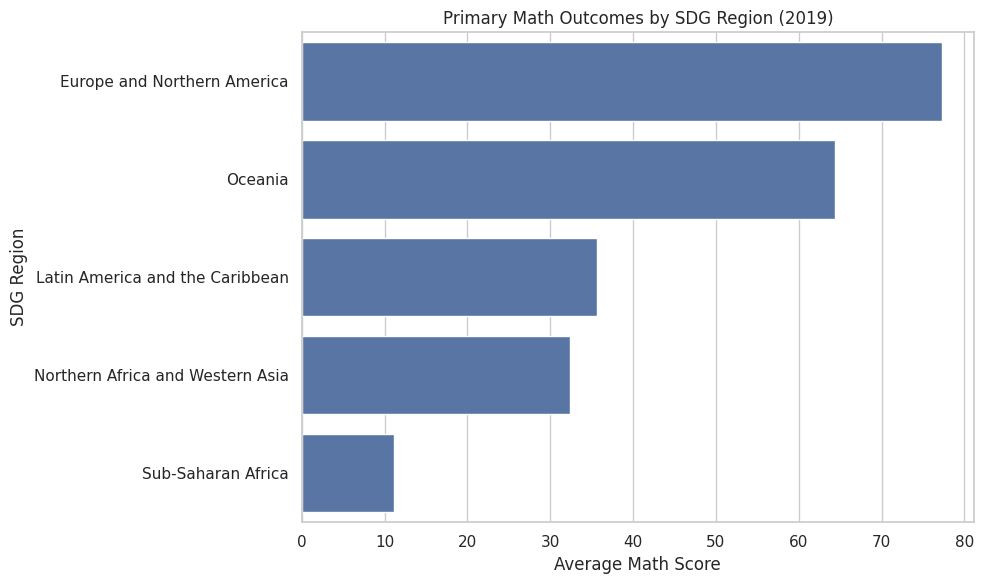

In [ ]:

math_sdg_regions["year"] = pd.to_numeric(math_sdg_regions["year"], errors="coerce")
math_sdg_regions["math_primary_score"] = pd.to_numeric(
    math_sdg_regions["math_primary_score"], errors="coerce"
)


latest_sdg_year = int(math_sdg_regions["year"].max())


plot_df = math_sdg_regions[math_sdg_regions["year"] == latest_sdg_year].copy()
plot_df = plot_df.sort_values("math_primary_score", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y="geo_group_name", x="math_primary_score")
plt.title(f"Primary Math Outcomes by SDG Region ({latest_sdg_year})")
plt.xlabel("Average Math Score")
plt.ylabel("SDG Region")
plt.tight_layout()
plt.show()

**Insight:**  
Higher scores in some regions and much lower scores in others indicate persistent
learning gaps that may contribute to later barriers in educational access.

## Average Primary Reading Performance Across SDG Regions

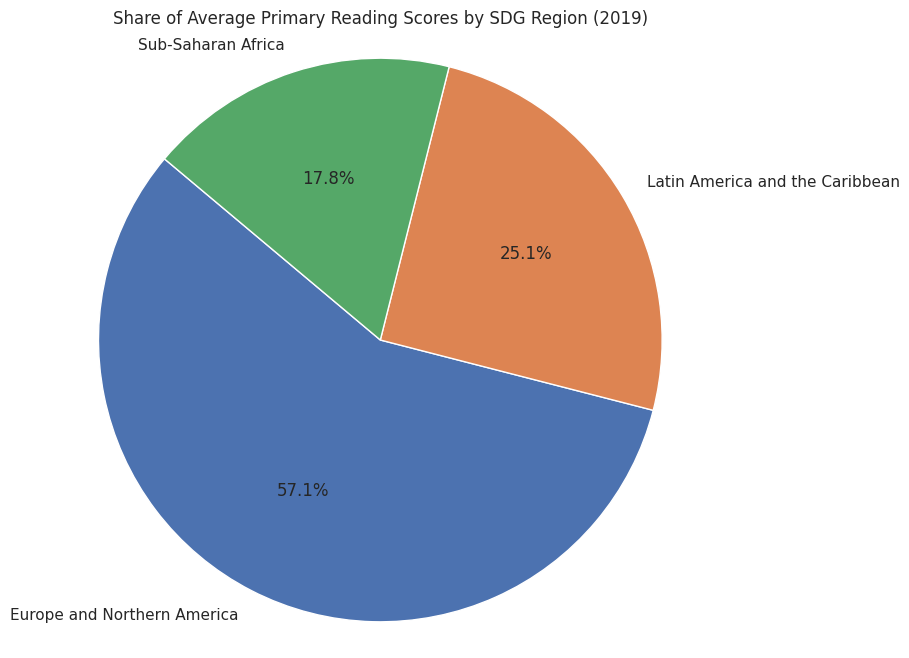

In [ ]:

read_sdg_regions = read_sdg[
    read_sdg["geo_group_name"].astype(str).str.strip().str.lower() != "world"
].copy()

read_sdg_regions["year"] = pd.to_numeric(read_sdg_regions["year"], errors="coerce")
read_sdg_regions["reading_primary_score"] = pd.to_numeric(
    read_sdg_regions["reading_primary_score"], errors="coerce"
)

latest_read_sdg_year = int(read_sdg_regions["year"].max())

plot_read = read_sdg_regions[read_sdg_regions["year"] == latest_read_sdg_year].copy()
plot_read = plot_read.dropna(subset=["geo_group_name", "reading_primary_score"])
plot_read = plot_read.sort_values("reading_primary_score", ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(
    plot_read["reading_primary_score"],
    labels=plot_read["geo_group_name"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title(f"Share of Average Primary Reading Scores by SDG Region ({latest_read_sdg_year})")
plt.axis("equal") 
plt.show()

**Insight:**  
The pie chart shows the relative distribution of average primary reading outcomes
across SDG regions, highlighting clear differences in regional learning levels.

*Note: The reading chart includes only the SDG regions available in the selected year after filtering and removing missing values.*

## Trend of Average Primary Math and Reading Outcomes Over Time (SDG Regions)

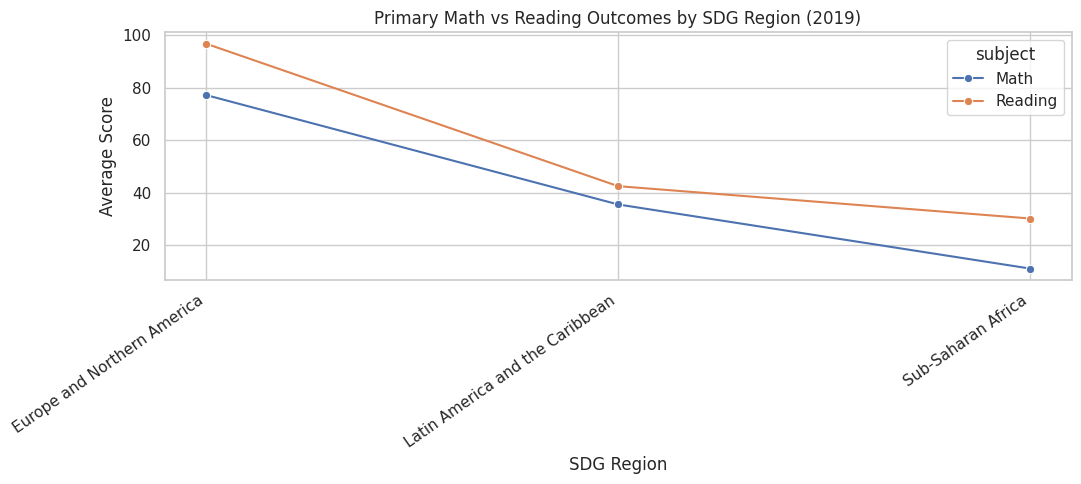

In [ ]:

math_cmp = math_sdg_regions[["year", "geo_group_name", "math_primary_score"]].copy()
read_cmp = read_sdg_regions[["year", "geo_group_name", "reading_primary_score"]].copy()

math_cmp["year"] = pd.to_numeric(math_cmp["year"], errors="coerce")
read_cmp["year"] = pd.to_numeric(read_cmp["year"], errors="coerce")

common_years = sorted(
    set(math_cmp["year"].dropna().astype(int)).intersection(
        set(read_cmp["year"].dropna().astype(int))
    )
)
comparison_year = max(common_years)

math_y = math_cmp[math_cmp["year"].astype(int) == comparison_year][["geo_group_name", "math_primary_score"]]
read_y = read_cmp[read_cmp["year"].astype(int) == comparison_year][["geo_group_name", "reading_primary_score"]]

compare_df = pd.merge(math_y, read_y, on="geo_group_name", how="inner")


compare_df["avg"] = (compare_df["math_primary_score"] + compare_df["reading_primary_score"]) / 2
compare_df = compare_df.sort_values("avg", ascending=False)

compare_long = compare_df.melt(
    id_vars="geo_group_name",
    value_vars=["math_primary_score", "reading_primary_score"],
    var_name="subject",
    value_name="score"
)

compare_long["subject"] = compare_long["subject"].replace({
    "math_primary_score": "Math",
    "reading_primary_score": "Reading"
})

region_order = compare_df["geo_group_name"].tolist()
compare_long["geo_group_name"] = pd.Categorical(compare_long["geo_group_name"], categories=region_order, ordered=True)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=compare_long.sort_values("geo_group_name"),
    x="geo_group_name",
    y="score",
    hue="subject",
    marker="o",
    sort=False
)

plt.title(f"Primary Math vs Reading Outcomes by SDG Region ({comparison_year})")
plt.xlabel("SDG Region")
plt.ylabel("Average Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Insight:**  
The line comparison shows regional differences between math and reading outcomes
and helps visualize whether numeracy performance falls below literacy performance across the same regions.

### Conclusion

The results show regional differences in primary-level math and reading outcomes,
indicating uneven learning conditions for refugee learners. While this dataset
does not directly measure higher education access, it provides useful early
signals of academic gaps that may affect future readiness and participation in
higher education.